In [45]:
import pandas as pd

In [46]:
train = pd.read_csv("train_final.csv")
test = pd.read_csv("test_final.csv")

## Exploratory Data Analysis and Forecast Modeling
This notebook performs dataset exploration for `train_final.csv` and `test_final.csv`, then builds a strong CatBoost forecasting model to predict `demand` for the test split.

The process includes:
- data overview and missing value checks
- holiday, category, and temporal demand patterns
- feature engineering for date and categorical features
- holdout-based validation on the last 28 days of training data
- CatBoost regression and submission creation

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

train = pd.read_csv("train_final.csv", parse_dates=["date"])
test = pd.read_csv("test_final.csv", parse_dates=["date"])

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train date range:", train["date"].min(), "to", train["date"].max())
print("Test date range:", test["date"].min(), "to", test["date"].max())
print("Unique stores:", train["store_id"].nunique())
print("Unique products:", train["product_id"].nunique())
print("Missing values:\n", train.isna().sum())
print("\nDemand summary:\n", train["demand"].describe())

train["holiday_name"] = train["holiday_name"].fillna("None")
test["holiday_name"] = test["holiday_name"].fillna("None")
train["price"] = train["price"].fillna(train["price"].median())
test["price"] = test["price"].fillna(train["price"].median())

for df in [train, test]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["week"] = df["date"].dt.isocalendar().week.astype(int)
    df["quarter"] = df["date"].dt.quarter
    df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
    df["is_month_end"] = df["date"].dt.is_month_end.astype(int)

train.head(5)

Train shape: (421080, 13)
Test shape: (8120, 12)
Train date range: 2023-05-15 00:00:00 to 2025-05-10 00:00:00
Test date range: 2025-05-11 00:00:00 to 2025-05-24 00:00:00
Unique stores: 10
Unique products: 58
Missing values:
 row_id               0
date                 0
store_id             0
city                 0
region               0
product_id           0
product_name         0
category             0
price            58014
loyalty_day          0
is_holiday           0
holiday_name    395560
demand               0
dtype: int64

Demand summary:
 count    421080.000000
mean          1.370117
std           2.764171
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max         119.000000
Name: demand, dtype: float64


,row_id,date,store_id,city,region,product_id,product_name,category,price,loyalty_day,...,holiday_name,demand,year,month,day,dayofweek,week,quarter,is_month_start,is_month_end
0,725,2025-05-10,CM-BAC-01,Bacău,Moldova,P0001,Apă plată 2L,Beverages,4.08,0,...,None,7,2025,5,10,5,19,2,0,0
1,1451,2025-05-10,CM-BAC-01,Bacău,Moldova,P0002,Apă minerală carbogazoasă 1.5L,Beverages,8.68,0,...,None,8,2025,5,10,5,19,2,0,0
2,2177,2025-05-10,CM-BAC-01,Bacău,Moldova,P0003,Cola 2L,Beverages,9.73,0,...,None,2,2025,5,10,5,19,2,0,0
3,2903,2025-05-10,CM-BAC-01,Bacău,Moldova,P0004,Suc natural portocale 1L,Beverages,8.60,0,...,None,0,2025,5,10,5,19,2,0,0
4,3629,2025-05-10,CM-BAC-01,Bacău,Moldova,P0005,Bere lager 0.5L,Beverages,4.26,0,...,None,0,2025,5,10,5,19,2,0,0


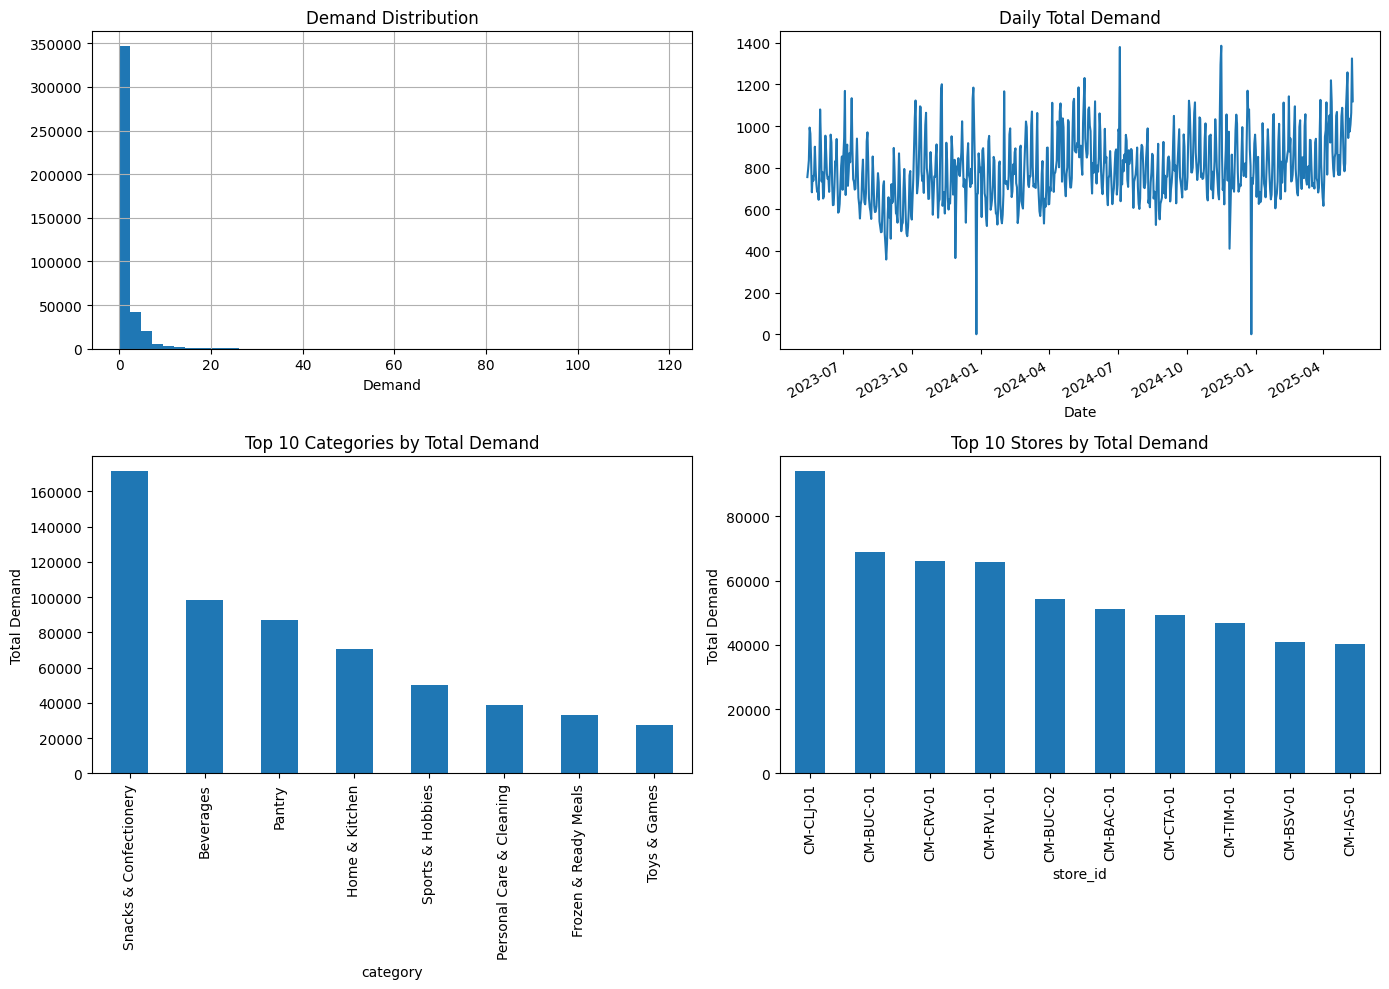

   is_holiday      mean  median   count
0           0  1.366273     0.0  395560
1           1  1.429702     0.0   25520
Test products in train: 58 | overlap with train: 1.0
Test stores in train: 10 | overlap with train: 1.0


In [48]:
# Demand distribution and aggregated patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

train["demand"].hist(bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Demand Distribution")
axes[0, 0].set_xlabel("Demand")

train.groupby("date")["demand"].sum().plot(ax=axes[0, 1])
axes[0, 1].set_title("Daily Total Demand")
axes[0, 1].set_xlabel("Date")

train.groupby("category")["demand"].sum().sort_values(ascending=False).head(10).plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Top 10 Categories by Total Demand")
axes[1, 0].set_ylabel("Total Demand")

train.groupby("store_id")["demand"].sum().sort_values(ascending=False).head(10).plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Top 10 Stores by Total Demand")
axes[1, 1].set_ylabel("Total Demand")

plt.tight_layout()
plt.show()

# Holiday effect
holiday_summary = train.groupby(["is_holiday"])["demand"].agg(["mean", "median", "count"]).reset_index()
print(holiday_summary)

# Verify train/test alignment
print("Test products in train:", test["product_id"].nunique(), "| overlap with train:", test["product_id"].isin(train["product_id"]).mean())
print("Test stores in train:", test["store_id"].nunique(), "| overlap with train:", test["store_id"].isin(train["store_id"]).mean())

You should provide test set for use best model. use_best_model parameter has been switched to false value.


0:	learn: 2.7323614	total: 60.9ms	remaining: 1m 25s
100:	learn: 2.2453948	total: 4.11s	remaining: 52.8s
200:	learn: 2.1728702	total: 8.81s	remaining: 52.5s
300:	learn: 2.1290715	total: 13.5s	remaining: 49.2s
400:	learn: 2.1083084	total: 18.3s	remaining: 45.5s
500:	learn: 2.0903825	total: 22.9s	remaining: 41s
600:	learn: 2.0769179	total: 27.5s	remaining: 36.6s
700:	learn: 2.0630218	total: 32.3s	remaining: 32.2s
800:	learn: 2.0544157	total: 37s	remaining: 27.6s
900:	learn: 2.0432599	total: 41.5s	remaining: 23s
1000:	learn: 2.0365037	total: 46.3s	remaining: 18.4s
1100:	learn: 2.0288704	total: 50.9s	remaining: 13.8s
1200:	learn: 2.0233366	total: 55.4s	remaining: 9.17s
1300:	learn: 2.0187865	total: 1m	remaining: 4.57s
1399:	learn: 2.0130056	total: 1m 4s	remaining: 0us
Validation RMSE: 2.1223
           feature  importance
3       product_id   32.666435
6            price   17.534599
13            week   11.572817
4         category   10.038420
0         store_id    7.748980
10           mon

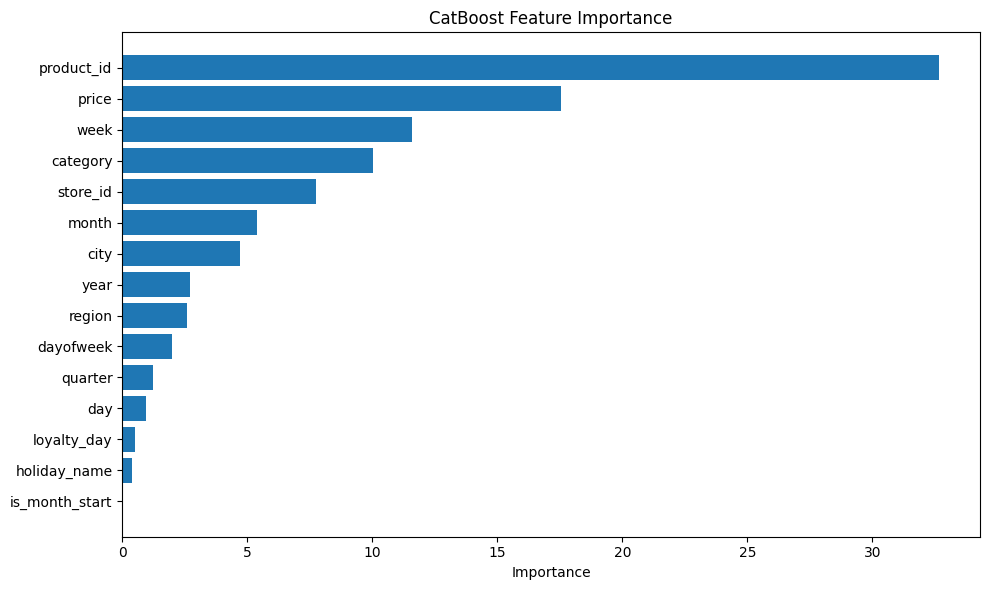

In [49]:
# Model training with CatBoost
features = [
    "store_id",
    "city",
    "region",
    "product_id",
    "category",
    "holiday_name",
    "price",
    "loyalty_day",
    "is_holiday",
    "year",
    "month",
    "day",
    "dayofweek",
    "week",
    "quarter",
    "is_month_start",
    "is_month_end",
]

categorical_features = [
    "store_id",
    "city",
    "region",
    "product_id",
    "category",
    "holiday_name",
]

cutoff_date = train["date"].max() - pd.Timedelta(days=28)
train_mask = train["date"] <= cutoff_date
valid_mask = train["date"] > cutoff_date

X_train = train.loc[train_mask, features]
Y_train = train.loc[train_mask, "demand"]
X_valid = train.loc[valid_mask, features]
Y_valid = train.loc[valid_mask, "demand"]

model = CatBoostRegressor(
    iterations=1400,
    learning_rate=0.05,
    depth=5,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    cat_features=categorical_features,
    verbose=100,
    early_stopping_rounds=50,
)

model.fit(train[features], train["demand"], use_best_model=True)

valid_preds = model.predict(X_valid)
val_rmse = np.sqrt(mean_squared_error(Y_valid, valid_preds))
print(f"Validation RMSE: {val_rmse:.4f}")

# feature importance
importance = pd.DataFrame({
    "feature": model.feature_names_,
    "importance": model.feature_importances_,
}).sort_values(by="importance", ascending=False)
print(importance.head(15))

plt.figure(figsize=(10, 6))
plt.barh(importance["feature"].head(15)[::-1], importance["importance"].head(15)[::-1])
plt.title("CatBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [52]:
# Predict on test and export submission
X_test = test[features]
predictions = model.predict(X_test)

submission = test[["row_id"]].copy()
submission["demand"] = predictions
submission.to_csv("submission.csv", index=False)

print("Submission sample:")
print(submission.head(10).to_string(index=False))
print("Saved submission.csv with", submission.shape[0], "rows")


Submission sample:
 row_id   demand
      0 7.393537
      1 2.257563
      2 1.860877
      3 0.894161
      4 0.808839
      5 0.595904
      6 0.731535
      7 3.099270
      8 2.126523
      9 1.665461
Saved submission.csv with 8120 rows
